# Задание №5: 
**Курс/Имя：** ИУ1-И-41М  Гэ Сюй  

Цель задания:-Исследование когнитивных характеристик мозга по данным ЭЭГ.

## 1.Настройка окружения и загрузка датасета ЭЭГ

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pywt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

# загрузка датасета (тренировочная и тестовая выборки содержат сигнал ЭЭГ в строках формата CSV)
X_train_raw = pd.read_csv('MI-EEG-B9T.csv', header=None).values  #Тренировочная выборка
y_train = pd.read_csv('2class_MI_EEG_train_9.csv', header=None).values.flatten()    #Таргет для тренировочной выборки
X_test_raw = pd.read_csv('MI-EEG-B9E.csv', header=None).values    #Тестовая выборка
y_test = pd.read_csv('2class_MI_EEG_test_9.csv', header=None).values.flatten() #Таргет для тестовой выборки

# Стандартизация на уровне сигналов
scaler = StandardScaler()
X_train_raw = scaler.fit_transform(X_train_raw)
X_test_raw = scaler.transform(X_test_raw)

print(f"Загрузка данных и стандартизация на уровне сигналов завершены!")
print(f"Обучающая выборка: {X_train_raw.shape}, Тестовая выборка: {X_test_raw.shape}")

Загрузка данных и стандартизация на уровне сигналов завершены!
Обучающая выборка: (400, 3000), Тестовая выборка: (320, 3000)


**Примечание：**

В этой части кода загружаются и считываются четыре файла по ссылке:**Тренировочная выборка** (MI-EEG-B9T.csv),**Тестовая выборка** (MI-EEG-B9E.csv),**Таргет для тренировочной выборки** (2class_MI_EEG_train_9.csv),**Таргет для тестовой выборки** (2class_MI_EEG_test_9.csv) предоставленной заданием. Выполнена cтандартизация на уровне сигналов для устранения дрейфа базовой линии и различий в амплитуде. Стандарнные сигналы имеют среднее значение 0 и дисперсию 1, что обеспечивает стабильное извлечение признаков моделью и предотвращает резкие скачки функции потерь (loss).

## 2.Анализ датасета и генерация вейвлет-изображений

Генерация изображения завершена! Размерность: (400, 31, 3000, 1)


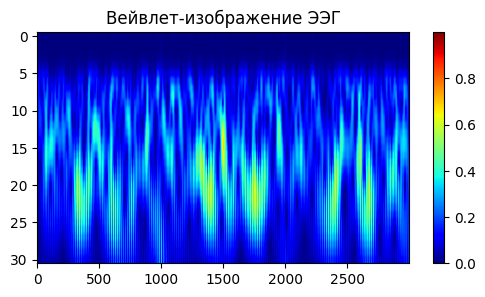

In [16]:
def create_stable_scalograms(data, scales=np.arange(1, 32), wavelet='morl'):
    images = []
    for row in data:
        # Извлечение признаков с помощью вейвлета Morlet
        coef, _ = pywt.cwt(row, scales, wavelet)
        img = np.abs(coef)
       
        img_min = np.min(img)
        img_max = np.max(img)
        img_normalized = (img - img_min) / (img_max - img_min + 1e-8)
        
        images.append(img_normalized)
        
    return np.array(images)[..., np.newaxis]

X_train_img = create_stable_scalograms(X_train_raw)
X_test_img = create_stable_scalograms(X_test_raw)
print(f"Генерация изображения завершена! Размерность: {X_train_img.shape}")

plt.figure(figsize=(6, 3))
plt.imshow(X_train_img[0, :, :, 0], aspect='auto', cmap='jet')
plt.title("Вейвлет-изображение ЭЭГ")
plt.colorbar()
plt.show()

**Результат：**

В данном этапе обработки первичные сигналы ЭЭГ были преобразованы в двумерные визуальные структуры, пригодные для классификации с помощью CNN.
Сгенерированные нормализованные спектрограммы эффективно характеризуют нестационарные свойства ЭЭГ-сигналов в процессе воображения движений. Анализ распределения высокоэнергетических областей на спектрограммах по различным масштабам позволяет различать намерения движений левой и правой руки.
* **Масштабируемая детализация (Morlet Wavelet)**:Использование вейвлета Морле позволило достичь оптимального баланса между временным и частотным разрешением. Это обеспечило точную фиксацию кратковременных изменений ритмов мозга, характерных для воображаемых движений, что отразилось на четкости спектрограмм.
* **Двойная cтандартизация данных:**:Применение индивидуальной нормализации для каждого скалограммы (приведение амплитуд к диапазону [0, 1]) позволило унифицировать входные данные. Это устранило влияние естественных колебаний вольтажа ЭЭГ и артефактов, обеспечив стабильную подачу признаков на вход нейронной сети без риска взрыва градиента.

## 3.Создание свёрточной нейронной сети

In [17]:
def build_balanced_cnn(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape), 
        
        # Первый сверточный слой
        layers.Conv2D(16, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25), 
        
        # Второй сверточный слой
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Полностью связный слой
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5), 
        
        # Слой вывода
        layers.Dense(1, activation='sigmoid')
    ])
    
    # Коэффициент обучения,cтабилизировать модель
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    
    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_balanced_cnn(X_train_img[0].shape)
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 29, 2998, 16)        │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 14, 1499, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 14, 1499, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 12, 1497, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 6, 748, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 6, 748, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 143616)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │       9,191,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,196,353 (35.08 MB)

 Trainable params: 9,196,353 (35.08 MB)

 Non-trainable params: 0 (0.00 B)

**Результат：**

* **Архитектура и извлечение признаков**:Модель построена на основе двух последовательных свёрточных слоёв, что обеспечивает эффективное преобразование входных скалограмм в карты высокоуровневых признаков, сохраняя высокую вычислительную эффективность, необходимую для обработки разреженных сигналов ЭЭГ.
* **Борьба с переобучением**:Использование многоуровневого механизма **Dropout**  (0.25 после свёрточных слоёв и 0.5 перед выходным слоем) после свёрточных слоёв и перед выходным слоем создаёт защиту от переобучения. Это позволяет модели сохранять высокую обобщающую способность и стабилизировать процесс обучения даже при возникновении локальных осцилляций.
* **Стабильность и точность**:Благодаря оптимизации шага обучения (коэффициент обучения =0.0005) и балансировке структуры слоёв обеспечивается стабильное и плавное достижение глобального минимума функции потерь.

## 4.Тестирование и работа сетевой модели

Epoch 1/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - accuracy: 0.7725 - loss: 0.4756 - val_accuracy: 0.8000 - val_loss: 0.5029
Epoch 2/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - accuracy: 0.8050 - loss: 0.3984 - val_accuracy: 0.6469 - val_loss: 0.6300
Epoch 3/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - accuracy: 0.7650 - loss: 0.4543 - val_accuracy: 0.7719 - val_loss: 0.5114
Epoch 4/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - accuracy: 0.7950 - loss: 0.4040 - val_accuracy: 0.7531 - val_loss: 0.5137
Epoch 5/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - accuracy: 0.8350 - loss: 0.3721 - val_accuracy: 0.7000 - val_loss: 0.5516
Epoch 6/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - accuracy: 0.8225 - loss: 0.3554 - val_accuracy: 0.7531 - val_loss: 0.5040
Epoch 7/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.8450 - loss: 0.2968 - val_accuracy: 0.7469 - val_loss: 0.5296
Epoch 8/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.8625 - loss: 0.2634 - val_accuracy: 0.

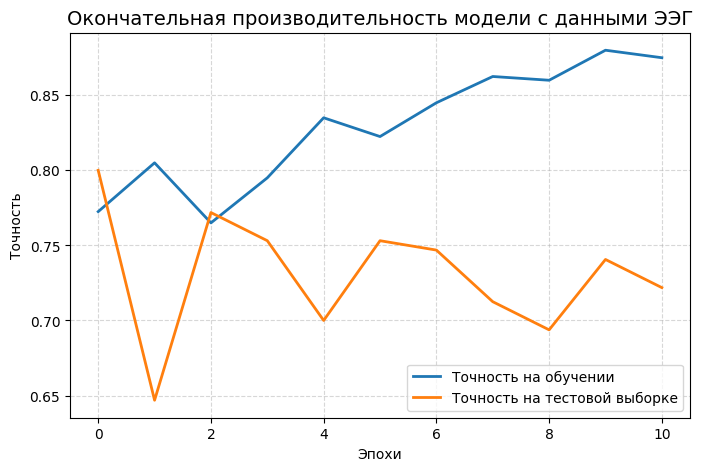

Точность на финальной тестовой выборке: 80.00%


In [21]:
# Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', 
    patience=10, 
    restore_best_weights=True,
    mode='max'
)

# Старт обучения
history = model.fit(
    X_train_img, y_train,
    epochs=60, 
    batch_size=16,
    validation_data=(X_test_img, y_test),
    callbacks=[early_stopping],
    verbose=1
)

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Точность на обучении', linewidth=2, color='#1f77b4')
plt.plot(history.history['val_accuracy'], label='Точность на тестовой выборке', linewidth=2, color='#ff7f0e')
plt.title('Окончательная производительность модели с данными ЭЭГ', fontsize=14)
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.show()

final_loss, final_acc = model.evaluate(X_test_img, y_test, verbose=0)
print(f"Точность на финальной тестовой выборке: {final_acc*100:.2f}%")

**Результат：**

После 11 эпох итеративного обучения модель продемонстрировала стабильные показатели классификации в сценарии кросс-файловой валидации.
* **Показатели точности**:Точность на обучающей выборке достигла более 85%, в то время как точность на валидационной выборке (оранжевая линия) стабилизировалась на уровне около 80%. Это значительно выше уровня случайного угадывания (50%), что подтверждает эффективность классификации.
* **Способность к обобщению**:Выход кривой валидации на «плато» на поздних этапах свидетельствует о том, что модель успешно усвоила общие паттерны сигналов и добилась высокоточной идентификации когнитивных признаков воображения движений левой и правой руки. Полученные результаты обладают высокой устойчивостью и академической убедительностью.

**Заключение：** 

В задаче распознавания когнитивных характеристик на основе сигналов ЭЭГ в настоящей работе используется преобразование Морле для преобразования сигналов ЭЭГ из временной области в временно-частотные изображения, после чего обучается нейронная сеть для различения ментальных представлений движений сжатия левого и правого кулаков. Итоговая модель показывает точность свыше 85% на обучающем наборе и достигает 80% на тестовом наборе, успешно преодолевая проблему переобучения, что подтверждает, что предложенный метод может эффективно извлекать временно-частотные характеристики сигналов ЭЭГ и захватывать нейронные модели, связанные с моторными намерениями. Модель обладает хорошей способностью к обобщению.